<a href="https://colab.research.google.com/github/AiWriter404/AI-With-Python-Digiskills/blob/main/Ai_With_Python_W5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Topic 84 Creating New Features from Existing Data

In [4]:
# Load Dataset
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Ai_with_python/datasets/telecom_customer_churn_feature_engineering.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
0,10001,2019-01-01,65,Male,Multan,Bachelor,Employed,57643.0,10049.0,5.8,52.0,6-Month,1,Coverage is poor in my location,0
1,10002,2019-01-02,22,Female,Peshawar,Master,Employed,18207.0,2752.0,11.9,22.0,6-Month,2,Billing issues occurred multiple times,0
2,10003,2019-01-03,43,Male,Gujranwala,Secondary,Employed,13075.0,3155.0,40.0,87.0,Monthly,0,Billing issues occurred multiple times,0
3,10004,2019-01-04,21,Male,Lahore,Secondary,Employed,38890.0,5859.0,8.5,147.0,6-Month,2,Customer support was helpful,0
4,10005,2019-01-05,37,Female,Hyderabad,Primary,Employed,17475.0,5106.0,3.3,183.0,12-Month,0,Coverage is poor in my location,0


In [6]:
# --- 1. Date Part Extraction ---
# Signup date ko datetime object mein convert karna
df["signup_date"] = pd.to_datetime(df["signup_date"])

In [8]:
# Date se Year, Month, aur Day of Week (DOW) ke naye columns nikalna
df["signup_year"] = df["signup_date"].dt.year
df["signup_month"] = df["signup_date"].dt.month
df["signup_dow"] = df["signup_date"].dt.dayofweek

In [10]:
# Naye date features ko check karna
df[["signup_date", "signup_year", "signup_month", "signup_dow"]].head()

,signup_date,signup_year,signup_month,signup_dow
0,2019-01-01,2019,1,1
1,2019-01-02,2019,1,2
2,2019-01-03,2019,1,3
3,2019-01-04,2019,1,4
4,2019-01-05,2019,1,5


In [12]:
# --- 2. Ratio Feature Creation ---
# Income ke mutabiq bill ki ratio nikalna (Higher ratio = Zyada financial pressure)
df["bill_to_income_ratio"] = df["monthly_bill"] / df["monthly_income"]

# Verification check
df[["monthly_bill", "monthly_income", "bill_to_income_ratio"]].head()

,monthly_bill,monthly_income,bill_to_income_ratio
0,10049.0,57643.0,0.174332
1,2752.0,18207.0,0.151151
2,3155.0,13075.0,0.241300
3,5859.0,38890.0,0.150656
4,5106.0,17475.0,0.292189


In [14]:
# --- 3. Interaction Feature ---
# Do columns ko multiply kar ke naya feature banana (Tickets * Bill = Zyada gussa/frustration)
df["support_bill_interaction"] = df["support_tickets"] * df["monthly_bill"]

# Verification check
df[["support_tickets", "monthly_bill", "support_bill_interaction"]].head()

,support_tickets,monthly_bill,support_bill_interaction
0,1,10049.0,10049.0
1,2,2752.0,5504.0
2,0,3155.0,0.0
3,2,5859.0,11718.0
4,0,5106.0,0.0


In [16]:
# --- 4. Text Length Feature ---
# Customer feedback ke text ki length (chars count) ka naya column banana
df["feedback_length"] = df["customer_feedback"].str.len()

# Verification check
df[["customer_feedback", "feedback_length"]].head()

,customer_feedback,feedback_length
0,Coverage is poor in my location,31
1,Billing issues occurred multiple times,38
2,Billing issues occurred multiple times,38
3,Customer support was helpful,28
4,Coverage is poor in my location,31


In [18]:
# --- 5. Keyword Flag Feature ---
# Specific negative words ko dhoond kar 1 ya 0 ka flag (Binary feature) lagana
df["complaint_flag"] = df["customer_feedback"].str.contains(
    "slow|poor|expensive|unreliable|drops",
    case=False
).astype(int)

In [20]:
# Verification check
df[["customer_feedback", "complaint_flag"]].head()

,customer_feedback,complaint_flag
0,Coverage is poor in my location,1
1,Billing issues occurred multiple times,0
2,Billing issues occurred multiple times,0
3,Customer support was helpful,0
4,Coverage is poor in my location,1


In [22]:
# --- 6. Final Feature Review ---
# Tamam naye banaye gaye features ka aik sath preview dekhna
df[[
    "signup_month",
    "bill_to_income_ratio",
    "support_bill_interaction",
    "feedback_length",
    "complaint_flag"
]].head()

,signup_month,bill_to_income_ratio,support_bill_interaction,feedback_length,complaint_flag
0,1,0.174332,10049.0,31,1
1,1,0.151151,5504.0,38,0
2,1,0.241300,0.0,38,0
3,1,0.150656,11718.0,28,0
4,1,0.292189,0.0,31,1


In [24]:
import pandas as pd
import numpy as np
df=pd.DataFrame({
    "sales": [100,200,150,300,5000,700,3000,1500,400,600] # 5000 in an outleir
})
print(df.describe())

             sales
count    10.000000
mean   1195.000000
std    1603.546417
min     100.000000
25%     225.000000
50%     500.000000
75%    1300.000000
max    5000.000000


<function matplotlib.pyplot.show(close=None, block=None)>

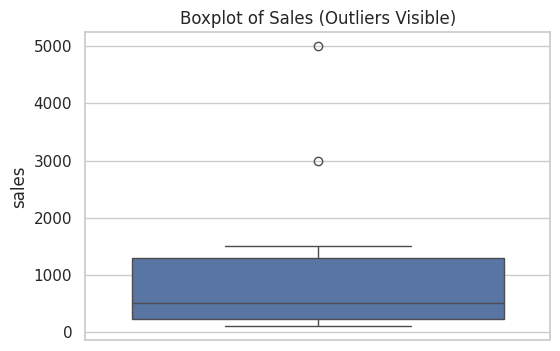

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.boxplot(y=df["sales"])
plt.title("Boxplot of Sales (Outliers Visible)")
plt.show


In [34]:
# clipping
df['sales_clipped']=df['sales'].clip(upper=1000)
print(df)

   sales  sales_clipped
0    100            100
1    200            200
2    150            150
3    300            300
4   5000           1000
5    700            700
6   3000           1000
7   1500           1000
8    400            400
9    600            600


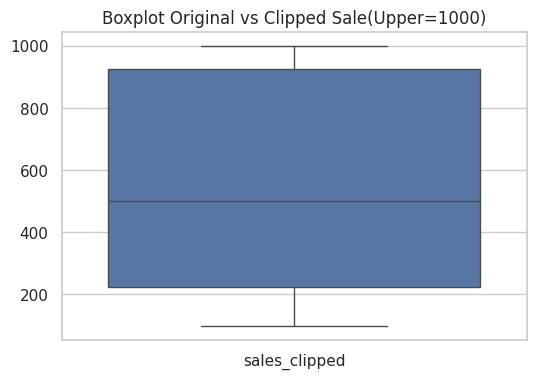

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
sns.boxplot(data=df[["sales_clipped"]])
plt.title("Boxplot Original vs Clipped Sale(Upper=1000)")
plt.show()

In [38]:
from scipy.stats.mstats import winsorize
df['sales_winsorized']=winsorize(df['sales'], limits=[0,0.02])
print(df)

   sales  sales_clipped  sales_winsorized
0    100            100               100
1    200            200               200
2    150            150               150
3    300            300               300
4   5000           1000              5000
5    700            700               700
6   3000           1000              3000
7   1500           1000              1500
8    400            400               400
9    600            600               600


In [43]:
# Removal Drop Outliers > 1000
df['sales_removed'] =df['sales'].where (df['sales'] <=1000, np.nan)
print(df)

   sales  sales_clipped  sales_winsorized  sales_removed
0    100            100               100          100.0
1    200            200               200          200.0
2    150            150               150          150.0
3    300            300               300          300.0
4   5000           1000              5000            NaN
5    700            700               700          700.0
6   3000           1000              3000            NaN
7   1500           1000              1500            NaN
8    400            400               400          400.0
9    600            600               600          600.0


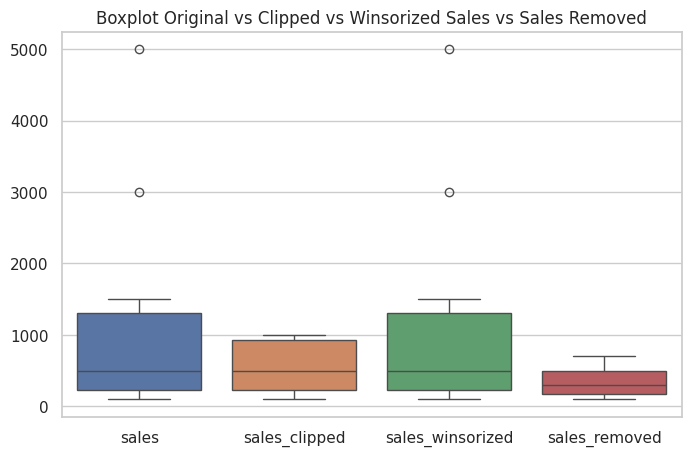

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["sales","sales_clipped","sales_winsorized","sales_removed"]])
plt.title("Boxplot Original vs Clipped vs Winsorized Sales vs Sales Removed")
plt.show()



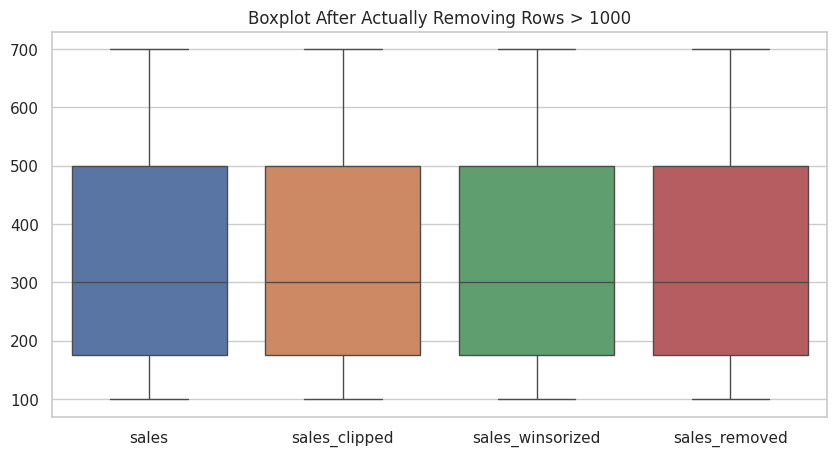

In [47]:
# FIX: Sirf wo rows filter karein jahan sales 1000 ya us se kam ho (Baqi rows permanently drop ho jayengi)
df_clean_rows = df[df['sales'] <= 1000]

# Ab plotting ke liye is naye df_clean_rows ko use karein
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(10,5))

# Purane columns ke sath naye cleaned dataframe ko plot karein
sns.boxplot(data=df_clean_rows[["sales", "sales_clipped", "sales_winsorized", "sales_removed"]])
plt.title("Boxplot After Actually Removing Rows > 1000")
plt.show()